In [11]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
# Importing imblearn, scikit-learn library
from imblearn.over_sampling import SMOTE
from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter


In [12]:
df = pd.read_excel("IAV-training.xlsx")
# df = pd.read_csv("final_training.csv")
df['Label'] = df['Label'].replace(np.nan, 0)
df=df.drop(["Residue_Index", "PDBID"], axis=1)
# df=df.drop(["Residue_Index", "PDBID", "Secondary_Structure", "Junction_Region","Chain"], axis=1)
df["Valine_Propensity"]=df["Valine_Propensity"].apply(lambda x:x*-1)
df["Serine_Propensity"]=df["Serine_Propensity"].apply(lambda x:x*-1)
df["Methionine_Propensity"]=df["Methionine_Propensity"].apply(lambda x:x*-1)
df["Threonine_Propensity"]=df["Threonine_Propensity"].apply(lambda x:x*-1)
df["Leucine_Propensity"]=df["Leucine_Propensity"].apply(lambda x:x*-1)
aa_to_number = {
    'A': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5,
    'G': 6, 'H': 7, 'I': 8, 'K': 9, 'L': 10,
    'M': 11, 'N': 12, 'P': 13, 'Q': 14, 'R': 15,
    'S': 16, 'T': 17, 'V': 18, 'W': 19, 'Y': 20
}
# label="PDBID"
# classes= df[label].unique().tolist()
# print(f"Label classes: {classes}")
# df[label]= df[label].map(classes.index)

# Convert Amino_Acid column to numbers
df['Amino_Acid'] = df['Amino_Acid'].map(aa_to_number)
df

,Amino_Acid,Arginine_Propensity,Tryptophan_Propensity,Tyrosine_Propensity,Valine_Propensity,Serine_Propensity,Methionine_Propensity,Threonine_Propensity,Leucine_Propensity,RelSASA,Secondary_Enum,Label
0,11,0.000000,0.0,0.0,-0.0,-0.000000,-0.000000,-0.0,-0.000000,0.783568,0.942029,0
1,4,0.000000,0.0,0.0,-0.0,-0.000000,-0.000000,-0.0,-0.000000,0.742773,0.942029,0
2,15,0.000000,0.0,0.0,-0.0,-0.000000,-0.000000,-0.0,-0.000000,0.592849,0.130701,0
3,8,0.142857,0.0,0.0,-0.0,-0.000000,-0.142857,-0.0,-0.142857,0.516733,0.130701,0
4,9,0.285714,0.0,0.0,-0.0,-0.000000,-0.000000,-0.0,-0.142857,0.942029,0.130701,0
...,...,...,...,...,...,...,...,...,...,...,...,...
3317,16,0.142857,0.0,0.0,-0.0,-0.142857,-0.000000,-0.0,-0.142857,0.435100,0.276250,0
3318,5,0.000000,0.0,0.0,-0.0,-0.142857,-0.000000,-0.0,-0.142857,0.731220,0.276250,0
3319,14,0.000000,0.0,0.0,-0.0,-0.000000,-0.000000,-0.0,-0.000000,0.695062,0.942029,0
3320,10,0.000000,0.0,0.0,-0.0,-0.000000,-0.000000,-0.0,-0.000000,0.942029,0.942029,0


In [13]:
X= df.drop('Label', axis=1)
y=df["Label"]

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# 1. Your dataset: X (n_samples, 1024), y (1 = positive, 0 = unlabeled)
# Example: Load your actual data here
# X = ... (your 1024D features)
# y = ... (labels: 1 = positive, 0 = unlabeled)

# Step 1: Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils import resample

# X: Your (n_samples, 1024) features
# y: Labels (1 = positive, 0 = unlabeled)

# Step 1: Separate positive and unlabeled
X_pos = X[y == 1]
X_unl = X[y == 0]

# Step 2: Hold out some positive data to estimate c = P(s=1|y=1)
X_pos_train, X_pos_val = train_test_split(X_pos, test_size=0.2, random_state=42)

# Step 3: Combine training data (positives + unlabeled)
X_unl_sampled = resample(X_unl, replace=False, n_samples=len(X_pos_train), random_state=42)

# Combine balanced training set
X_train = np.vstack([X_pos_train, X_unl_sampled])
y_train = np.hstack([np.ones(len(X_pos_train)), np.zeros(len(X_unl_sampled))])


# Step 4: Train a probabilistic classifier (e.g. Logistic Regression)
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# Step 5: Estimate c = P(s=1|y=1) from held-out positives
probs_val = clf.predict_proba(X_pos_val)[:, 1]
c = np.mean(probs_val)
print(f"Estimated c (P(s=1 | y=1)) = {c:.4f}")

# Step 6: Predict probabilities on all data
probs_all = clf.predict_proba(X)[:, 1]

# Step 7: Corrected probabilities: P(y=1|x) = P(s=1|x) / c
corrected_probs = probs_all / c
corrected_probs = np.clip(corrected_probs, 0, 1)

# Step 8: Classify: Use threshold (default 0.5)
y_pred = (corrected_probs >= 0.5).astype(int)

# Optional: Evaluate
# If you have some labeled test data (optional), use that here
# Otherwise, you can only inspect distributions
print("Classification complete.")


Estimated c (P(s=1 | y=1)) = 0.5081
Classification complete.


C:\Users\Vidhi\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Vidhi\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [16]:
len(X_unl)

2587

In [21]:
pd.DataFrame({"PU_Label_Prob": probs_all}).to_csv("probs_all.csv", index=False)

C:\Users\Vidhi\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


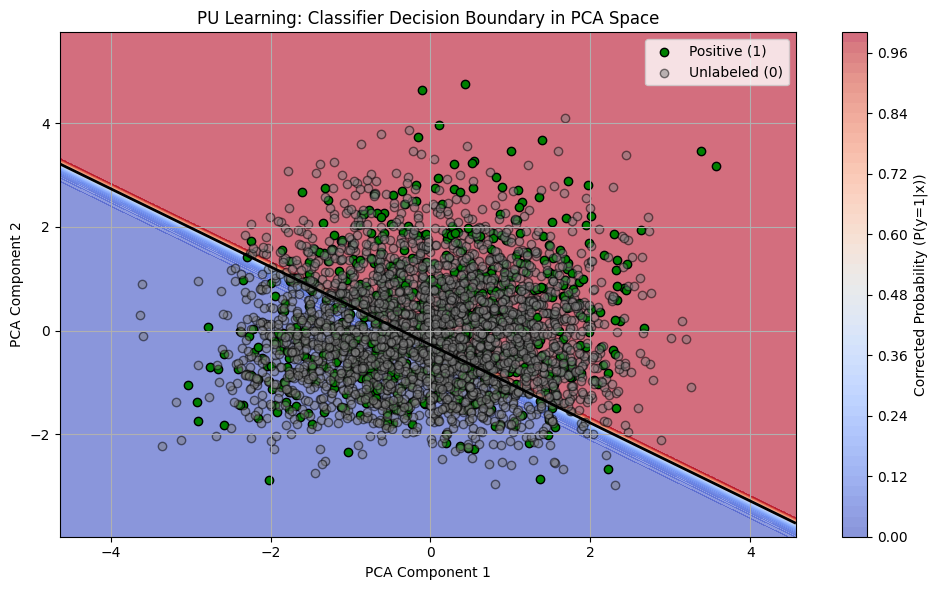

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Reduce features to 2D for plotting
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2. Plotting setup
plt.figure(figsize=(10, 6))

# 3. Plot the classifier's probability (as background heatmap)
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))
grid_pca = np.c_[xx.ravel(), yy.ravel()]

# Map the PCA grid back to original 1024D space
grid_orig = pca.inverse_transform(grid_pca)
grid_scaled = scaler.transform(grid_orig)

# Use the same classifier you trained
grid_probs = clf.predict_proba(grid_scaled)[:, 1] / c
grid_probs = np.clip(grid_probs, 0, 1)
Z = grid_probs.reshape(xx.shape)

# 4. Plot probability heatmap
contour = plt.contourf(xx, yy, Z, levels=50, cmap="coolwarm", alpha=0.6)
plt.colorbar(contour, label="Corrected Probability (P(y=1|x))")

# 5. Plot decision boundary (prob = 0.5)
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)

# 6. Plot data points
plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], c='green', label='Positive (1)', edgecolor='k')
plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], c='gray', label='Unlabeled (0)', edgecolor='k', alpha=0.5)

# 7. Final plot touches
plt.title("PU Learning: Classifier Decision Boundary in PCA Space")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
